In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('exportaciones_cuyo.csv')

print (f"Registros originales: {len(df)}")
print (f"Columnas: {df.columns.tolist()}")
print (f"\nPrimeras filas:")
print (df.head())

Registros originales: 3550
Columnas: ['ID_Envio', 'Region', 'Varietal', 'Destino', 'Botellas_Exportadas', 'Ingreso_Dolares']

Primeras filas:
   ID_Envio         Region Varietal Destino  Botellas_Exportadas  \
0     51726          Maipu   Malbec  Brasil                 1466   
1     52493          Maipu   Malbec  Brasil                 1013   
2     51759   Valle de Uco    Syrah  Brasil                 1626   
3     51671  Lujan de Cuyo    Syrah      UK                  770   
4     51368   Valle de Uco    Syrah   China                 1308   

   Ingreso_Dolares  
0     18884.461687  
1     24506.115090  
2     21792.604043  
3     15954.244739  
4     24095.256504  


In [5]:
df = df.drop_duplicates()
print (f"\nRegistros después de eliminar duplicados: {len(df)}")

mediana_ingresos = df['Ingreso_Dolares'].median()
print (f"\nMediana de Ingresos en Dólares: {mediana_ingresos}")

df['Ingreso_Dolares'] = df['Ingreso_Dolares'].fillna(mediana_ingresos)
print(f"Valores nulos restantes en Ingreso_Dolares: {df['Ingreso_Dolares'].isnull().sum()}")


Registros después de eliminar duplicados: 3505

Mediana de Ingresos en Dólares: 20143.19271460592
Valores nulos restantes en Ingreso_Dolares: 0


In [6]:
# Calcular Q1, Q3 e IQR
Q1 = df['Botellas_Exportadas'].quantile(0.25)
Q3 = df['Botellas_Exportadas'].quantile(0.75)
IQR = Q3 - Q1

# Definir límites para outliers
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Límites para outliers: [{limite_inferior}, {limite_superior}]")

# Contar outliers antes de eliminar
outliers = df[(df['Botellas_Exportadas'] < limite_inferior) | 
              (df['Botellas_Exportadas'] > limite_superior)]
print(f"Outliers detectados: {len(outliers)}")

# Eliminar outliers
df_limpio = df[(df['Botellas_Exportadas'] >= limite_inferior) & 
               (df['Botellas_Exportadas'] <= limite_superior)].copy()

print(f"Registros finales después de limpieza: {len(df_limpio)}")

Q1: 999.0, Q3: 1418.0, IQR: 419.0
Límites para outliers: [370.5, 2046.5]
Outliers detectados: 36
Registros finales después de limpieza: 3469


In [10]:
# Agrupar por 'Varietal' y calcular múltiples métricas en una sola línea
reporte_varietales = df_limpio.groupby('Varietal').agg(
    Total_Ingreso_Dolares=('Ingreso_Dolares', 'sum'),
    Promedio_Botellas=('Botellas_Exportadas', 'mean'),
    Total_Envios=('ID_Envio', 'count')
)

# Mostrar el resultado
print("Reporte por Varietal:")
print(reporte_varietales)

Reporte por Varietal:
                    Total_Ingreso_Dolares  Promedio_Botellas  Total_Envios
Varietal                                                                  
Cabernet Sauvignon           1.752736e+07        1215.304087           832
Chardonnay                   1.850990e+07        1197.536313           895
Malbec                       1.800730e+07        1218.576389           864
Syrah                        1.841338e+07        1197.493166           878


In [11]:
matriz_ejecutiva = df_limpio.pivot_table(
    values='Ingreso_Dolares',    
    index='Region',               
    columns='Destino',            
    aggfunc='sum',                
    fill_value=0                 
)
# Mostrar la matriz
print("Matriz Ejecutiva - Ingresos por Región y Destino:")
print(matriz_ejecutiva)

Matriz Ejecutiva - Ingresos por Región y Destino:
Destino              Brasil         China            UK           USA
Region                                                               
Lujan de Cuyo  4.625688e+06  4.587098e+06  4.505627e+06  4.091343e+06
Maipu          4.724301e+06  4.623504e+06  4.515820e+06  4.807866e+06
San Rafael     4.494860e+06  4.559144e+06  4.784179e+06  4.716358e+06
Valle de Uco   4.476648e+06  4.484535e+06  4.240113e+06  4.220846e+06


C:\Users\navar\AppData\Local\Temp\ipykernel_21880\4084830158.py:29: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\navar\AppData\Local\Temp\ipykernel_21880\4084830158.py:29: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\navar\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\navar\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


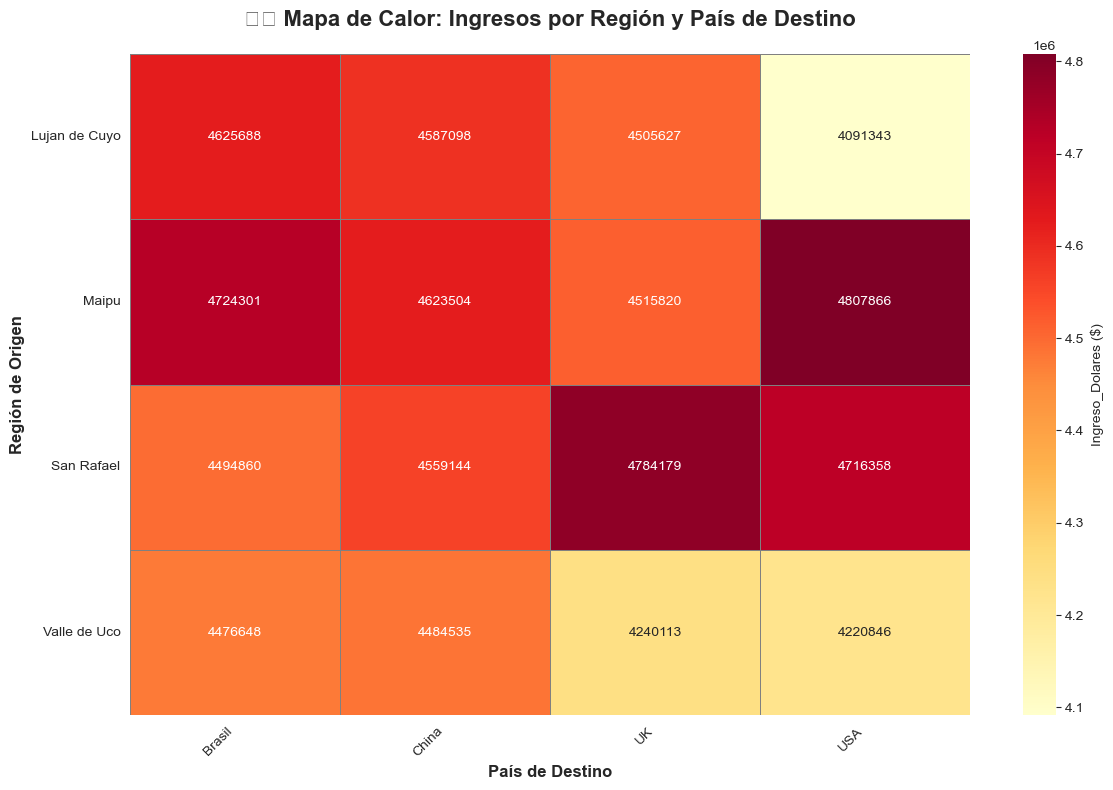

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
# Configurar el estilo visual
sns.set_style("white")
plt.figure(figsize=(12, 8))

# Crear el heatmap con la matriz ejecutiva
sns.heatmap(
    matriz_ejecutiva,
    annot=True,             
    fmt='.0f',              
    cmap='YlOrRd',          
    linewidths=0.5,         
    linecolor='gray',       
    cbar_kws={'label': 'Ingreso_Dolares ($)'}  
)

# Configurar títulos y etiquetas
plt.title('🗺️ Mapa de Calor: Ingresos por Región y País de Destino', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('País de Destino', fontsize=12, fontweight='bold')
plt.ylabel('Región de Origen', fontsize=12, fontweight='bold')

# Rotar etiquetas de columnas para mejor lectura
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Ajustar layout para evitar recortes
plt.tight_layout()

# Mostrar el gráfico
plt.show()